**生成式 AI 的使用**：在本作业中，生成式 AI 的使用须遵循与协作相同的政策。与其他协作者一样，每位学生都必须独立于交互输出自行写出解答，并且提交内容中应附注说明协作的性质。使用生成式 AI 工具完成作业的大部分内容不符合本作业的初衷，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'cs231n/assignments/assignment2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

ModuleNotFoundError: No module named 'google'

# 卷积网络

到目前为止，我们一直使用深度全连接网络来探索不同的优化策略和网络架构。全连接网络的计算效率很高，因此是很好的实验平台；但在实践中，所有最先进的成果都转而使用卷积网络。

首先，你将实现卷积网络中使用的几种层类型。随后，你将使用这些层在 CIFAR-10 数据集上训练一个卷积网络。

In [13]:
# Setup cell.
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.cnn import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient_array, eval_numerical_gradient
from cs231n.layers import *
from cs231n.fast_layers import *
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# 卷积：朴素前向传播

卷积网络的核心是卷积运算。请在文件 `cs231n/layers.py` 中的函数 `conv_forward_naive` 里实现卷积层的前向传播。

目前不用过多担心效率；只需用你认为最清晰的方式编写代码。

你可以运行以下代码来测试你的实现：

In [3]:
x_shape = (2, 3, 4, 4)
w_shape = (3, 3, 4, 4)
x = np.linspace(-0.1, 0.5, num=np.prod(x_shape)).reshape(x_shape)
w = np.linspace(-0.2, 0.3, num=np.prod(w_shape)).reshape(w_shape)
b = np.linspace(-0.1, 0.2, num=3)

conv_param = {'stride': 2, 'pad': 1}
out, _ = conv_forward_naive(x, w, b, conv_param)
correct_out = np.array([[[[-0.08759809, -0.10987781],
                           [-0.18387192, -0.2109216 ]],
                          [[ 0.21027089,  0.21661097],
                           [ 0.22847626,  0.23004637]],
                          [[ 0.50813986,  0.54309974],
                           [ 0.64082444,  0.67101435]]],
                         [[[-0.98053589, -1.03143541],
                           [-1.19128892, -1.24695841]],
                          [[ 0.69108355,  0.66880383],
                           [ 0.59480972,  0.56776003]],
                          [[ 2.36270298,  2.36904306],
                           [ 2.38090835,  2.38247847]]]])

# Compare your output to ours; difference should be around e-8
print('Testing conv_forward_naive')
print('difference: ', rel_error(out, correct_out))

Testing conv_forward_naive
difference:  2.2121476417505994e-08


## 补充：通过卷积进行图像处理

为了既有趣地检查你的实现，又更深入地理解卷积层能够执行的运算类型，我们将构造一个包含两幅图像的输入，并手动设置执行常见图像处理操作（灰度转换和边缘检测）的滤波器。卷积前向传播会将这些操作应用于每幅输入图像。然后，我们可以将结果可视化，以进行合理性检查。

C:\Users\lenovo\AppData\Local\Temp\ipykernel_19228\3128955772.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  kitten = imread('cs231n/notebook_images/kitten.jpg')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_19228\3128955772.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  puppy = imread('cs231n/notebook_images/puppy.jpg')


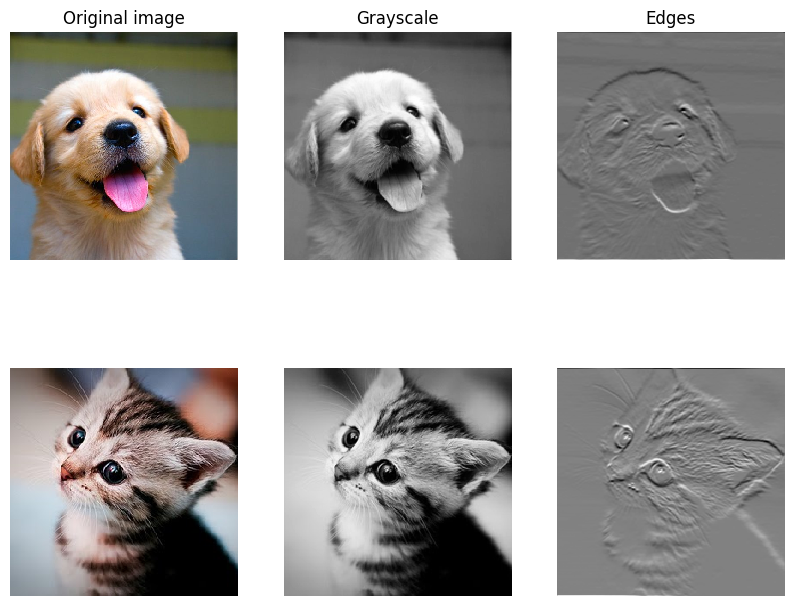

In [ ]:
from imageio import imread
from PIL import Image

kitten = imread('cs231n/notebook_images/kitten.jpg')
puppy = imread('cs231n/notebook_images/puppy.jpg')
# kitten is wide, and puppy is already square
d = kitten.shape[1] - kitten.shape[0]
kitten_cropped = kitten[:, d//2:-d//2, :]

img_size = 200   # Make this smaller if it runs too slow
resized_puppy = np.array(Image.fromarray(puppy).resize((img_size, img_size)))
resized_kitten = np.array(Image.fromarray(kitten_cropped).resize((img_size, img_size)))
x = np.zeros((2, 3, img_size, img_size))
x[0, :, :, :] = resized_puppy.transpose((2, 0, 1))
x[1, :, :, :] = resized_kitten.transpose((2, 0, 1))

# Set up a convolutional weights holding 2 filters, each 3x3
w = np.zeros((2, 3, 3, 3))

# The first filter converts the image to grayscale.
# Set up the red, green, and blue channels of the filter.
w[0, 0, :, :] = [[0, 0, 0], [0, 0.3, 0], [0, 0, 0]]
w[0, 1, :, :] = [[0, 0, 0], [0, 0.6, 0], [0, 0, 0]]
w[0, 2, :, :] = [[0, 0, 0], [0, 0.1, 0], [0, 0, 0]]

# Second filter detects horizontal edges in the blue channel.
w[1, 2, :, :] = [[1, 2, 1], [0, 0, 0], [-1, -2, -1]]

# Vector of biases. We don't need any bias for the grayscale
# filter, but for the edge detection filter we want to add 128
# to each output so that nothing is negative.
b = np.array([0, 128])

# Compute the result of convolving each input in x with each filter in w,
# offsetting by b, and storing the results in out.
out, _ = conv_forward_naive(x, w, b, {'stride': 1, 'pad': 1})

def imshow_no_ax(img, normalize=True):
    """ Tiny helper to show images as uint8 and remove axis labels """
    if normalize:
        img_max, img_min = np.max(img), np.min(img)
        img = 255.0 * (img - img_min) / (img_max - img_min)
    plt.imshow(img.astype('uint8'))
    plt.gca().axis('off')

# Show the original images and the results of the conv operation
plt.subplot(2, 3, 1)
imshow_no_ax(puppy, normalize=False)
plt.title('Original image')
plt.subplot(2, 3, 2)
imshow_no_ax(out[0, 0])
plt.title('Grayscale')
plt.subplot(2, 3, 3)
imshow_no_ax(out[0, 1])
plt.title('Edges')
plt.subplot(2, 3, 4)
imshow_no_ax(kitten_cropped, normalize=False)
plt.subplot(2, 3, 5)
imshow_no_ax(out[1, 0])
plt.subplot(2, 3, 6)
imshow_no_ax(out[1, 1])
plt.show()

# 卷积：朴素反向传播

请在文件 `cs231n/layers.py` 的函数 `conv_backward_naive` 中实现卷积运算的反向传播。同样，你不需要过多担心计算效率。

完成后，运行以下代码，通过数值梯度检查来验证你的反向传播。

_提示：可参考 https://deeplearning.cs.cmu.edu/F21/document/recitation/Recitation5/CNN_Backprop_Recitation_5_F21.pdf 了解总体思路。实际的朴素实现需要使用嵌套 for 循环，利用来自 dw 和 dout 的各项导数直接计算 dx_padded。_

In [ ]:
np.random.seed(231)
x = np.random.randn(4, 3, 5, 5)
w = np.random.randn(2, 3, 3, 3)
b = np.random.randn(2,)
dout = np.random.randn(4, 2, 5, 5)
conv_param = {'stride': 1, 'pad': 1}

dx_num = eval_numerical_gradient_array(lambda x: conv_forward_naive(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_forward_naive(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_forward_naive(x, w, b, conv_param)[0], b, dout)

out, cache = conv_forward_naive(x, w, b, conv_param)
dx, dw, db = conv_backward_naive(dout, cache)

# Your errors should be around e-8 or less.
print('Testing conv_backward_naive function')
print('dx error: ', rel_error(dx, dx_num))
print('dw error: ', rel_error(dw, dw_num))
print('db error: ', rel_error(db, db_num))

Testing conv_backward_naive function
dx error:  1.159803161159293e-08
dw error:  2.2471264748452487e-10
db error:  3.37264006649648e-11


# 最大池化：朴素前向传播

请在文件 `cs231n/layers.py` 的函数 `max_pool_forward_naive` 中实现最大池化运算的前向传播。同样，不用过多担心计算效率。

运行以下代码检查你的实现：

In [ ]:
x_shape = (2, 3, 4, 4)
x = np.linspace(-0.3, 0.4, num=np.prod(x_shape)).reshape(x_shape)
pool_param = {'pool_width': 2, 'pool_height': 2, 'stride': 2}

out, _ = max_pool_forward_naive(x, pool_param)

correct_out = np.array([[[[-0.26315789, -0.24842105],
                          [-0.20421053, -0.18947368]],
                         [[-0.14526316, -0.13052632],
                          [-0.08631579, -0.07157895]],
                         [[-0.02736842, -0.01263158],
                          [ 0.03157895,  0.04631579]]],
                        [[[ 0.09052632,  0.10526316],
                          [ 0.14947368,  0.16421053]],
                         [[ 0.20842105,  0.22315789],
                          [ 0.26736842,  0.28210526]],
                         [[ 0.32631579,  0.34105263],
                          [ 0.38526316,  0.4       ]]]])

# Compare your output with ours. Difference should be on the order of e-8.
print('Testing max_pool_forward_naive function:')
print('difference: ', rel_error(out, correct_out))

Testing max_pool_forward_naive function:
difference:  4.1666665157267834e-08


# 最大池化：朴素反向传播

请在文件 `cs231n/layers.py` 的函数 `max_pool_backward_naive` 中实现最大池化运算的反向传播。你不需要担心计算效率。

运行以下代码，通过数值梯度检查来验证你的实现：

In [ ]:
np.random.seed(231)
x = np.random.randn(3, 2, 8, 8)
dout = np.random.randn(3, 2, 4, 4)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

dx_num = eval_numerical_gradient_array(lambda x: max_pool_forward_naive(x, pool_param)[0], x, dout)

out, cache = max_pool_forward_naive(x, pool_param)
dx = max_pool_backward_naive(dout, cache)

# Your error should be on the order of e-12
print('Testing max_pool_backward_naive function:')
print('dx error: ', rel_error(dx, dx_num))

Testing max_pool_backward_naive function:
dx error:  3.27562514223145e-12


# 快速层

要让卷积层和池化层高效运行并不容易。为了省去这些麻烦，我们已在文件 `cs231n/fast_layers.py` 中提供了卷积层和池化层前向、反向传播的快速实现。

### 执行下面的单元，保存 notebook，然后重启运行时
快速卷积实现依赖一个 Cython 扩展；请运行下面的单元来编译它。接着，保存 Colab notebook（`File > Save`），并**重启运行时**（`Runtime > Restart runtime`）。之后可以从上到下重新执行前面的单元，并跳过下面这个单元，因为编译步骤只需运行一次。

In [ ]:
# Remember to restart the runtime after executing this cell!
%cd "C:/Users/lenovo/Desktop/cs by orbro/cs231n/assignment/assignment2/cs231n"
!python setup.py build_ext --inplace
%cd ..

C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2\cs231n


C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2


Traceback (most recent call last):
  File "C:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2\cs231n\setup.py", line 1, in <module>
    from setuptools import Extension, setup
ModuleNotFoundError: No module named 'setuptools'


卷积层和池化层快速版本的 API 与你在上面实现的朴素版本完全相同：前向传播接收数据、权重和参数，并生成输出与缓存对象；反向传播接收上游导数和缓存对象，并生成关于数据和权重的梯度。

**注意：**只有当池化区域互不重叠且恰好铺满输入时，池化的快速实现才能达到最佳性能。如果不满足这些条件，那么快速池化实现不会比朴素实现快多少。

你可以运行以下代码，对比这些层的朴素版本与快速版本的性能：

In [4]:
# Rel errors should be around e-9 or less.
from cs231n.fast_layers import conv_forward_fast, conv_backward_fast
from time import time
np.random.seed(231)
x = np.random.randn(100, 3, 31, 31)
w = np.random.randn(25, 3, 3, 3)
b = np.random.randn(25,)
dout = np.random.randn(100, 25, 16, 16)
conv_param = {'stride': 2, 'pad': 1}

t0 = time()
out_naive, cache_naive = conv_forward_naive(x, w, b, conv_param)
t1 = time()
out_fast, cache_fast = conv_forward_fast(x, w, b, conv_param)
t2 = time()

print('Testing conv_forward_fast:')
print('Naive: %fs' % (t1 - t0))
print('Fast: %fs' % (t2 - t1))
print('Speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('Difference: ', rel_error(out_naive, out_fast))

t0 = time()
dx_naive, dw_naive, db_naive = conv_backward_naive(dout, cache_naive)
t1 = time()
dx_fast, dw_fast, db_fast = conv_backward_fast(dout, cache_fast)
t2 = time()

print('\nTesting conv_backward_fast:')
print('Naive: %fs' % (t1 - t0))
print('Fast: %fs' % (t2 - t1))
print('Speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('dx difference: ', rel_error(dx_naive, dx_fast))
print('dw difference: ', rel_error(dw_naive, dw_fast))
print('db difference: ', rel_error(db_naive, db_fast))

Testing conv_forward_fast:
Naive: 2.250938s
Fast: 0.006498s
Speedup: 346.399450x
Difference:  2.95584471112945e-11

Testing conv_backward_fast:
Naive: 3.215834s
Fast: 0.007005s
Speedup: 459.078452x
dx difference:  1.0692258445766582e-11
dw difference:  5.617985857421359e-13
db difference:  3.481354613192702e-14


In [5]:
# Relative errors should be close to 0.0.
from cs231n.fast_layers import max_pool_forward_fast, max_pool_backward_fast
np.random.seed(231)
x = np.random.randn(100, 3, 32, 32)
dout = np.random.randn(100, 3, 16, 16)
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

t0 = time()
out_naive, cache_naive = max_pool_forward_naive(x, pool_param)
t1 = time()
out_fast, cache_fast = max_pool_forward_fast(x, pool_param)
t2 = time()

print('Testing pool_forward_fast:')
print('Naive: %fs' % (t1 - t0))
print('fast: %fs' % (t2 - t1))
print('speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('difference: ', rel_error(out_naive, out_fast))

t0 = time()
dx_naive = max_pool_backward_naive(dout, cache_naive)
t1 = time()
dx_fast = max_pool_backward_fast(dout, cache_fast)
t2 = time()

print('\nTesting pool_backward_fast:')
print('Naive: %fs' % (t1 - t0))
print('fast: %fs' % (t2 - t1))
print('speedup: %fx' % ((t1 - t0) / (t2 - t1)))
print('dx difference: ', rel_error(dx_naive, dx_fast))

Testing pool_forward_fast:
Naive: 0.163241s
fast: 0.003584s
speedup: 45.542238x
difference:  0.0

Testing pool_backward_fast:
Naive: 0.509069s
fast: 0.009998s
speedup: 50.916704x
dx difference:  0.0


# 卷积“夹心”层

在上一次作业中，我们介绍了“夹心”层的概念，即把多个操作组合成常用模式。在文件 `cs231n/layer_utils.py` 中，你会找到实现了若干卷积网络常用模式的夹心层。运行下面的单元，对其用法进行合理性检查。

In [6]:
from cs231n.layer_utils import conv_relu_pool_forward, conv_relu_pool_backward
np.random.seed(231)
x = np.random.randn(2, 3, 16, 16)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}
pool_param = {'pool_height': 2, 'pool_width': 2, 'stride': 2}

out, cache = conv_relu_pool_forward(x, w, b, conv_param, pool_param)
dx, dw, db = conv_relu_pool_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_pool_forward(x, w, b, conv_param, pool_param)[0], b, dout)

# Relative errors should be around e-8 or less
print('Testing conv_relu_pool')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu_pool
dx error:  4.397502834267091e-09
dw error:  3.651699397290073e-09
db error:  7.054812624223923e-10


In [7]:
from cs231n.layer_utils import conv_relu_forward, conv_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 8, 8)
w = np.random.randn(3, 3, 3, 3)
b = np.random.randn(3,)
dout = np.random.randn(2, 3, 8, 8)
conv_param = {'stride': 1, 'pad': 1}

out, cache = conv_relu_forward(x, w, b, conv_param)
dx, dw, db = conv_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: conv_relu_forward(x, w, b, conv_param)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: conv_relu_forward(x, w, b, conv_param)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: conv_relu_forward(x, w, b, conv_param)[0], b, dout)

# Relative errors should be around e-8 or less
print('Testing conv_relu:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing conv_relu:
dx error:  8.03522627181292e-09
dw error:  2.0902405745264502e-10
db error:  3.287958402642519e-10


# 三层卷积网络

现在你已经实现了所有必需的层，可以把它们组合成一个简单的卷积网络。

打开文件 `cs231n/classifiers/cnn.py`，完成 `ThreeLayerConvNet` 类的实现。请记住，你可以在实现中使用快速层/夹心层（已为你导入）。运行以下单元来帮助调试：

## 损失的合理性检查

构建一个新网络后，首先应该做的事情之一就是对损失进行合理性检查。使用 softmax 损失时，对于随机权重（且无正则化），我们预期 `C` 个类别的损失约为 `log(C)`。加入正则化后，损失应略微上升。

In [9]:
model = ThreeLayerConvNet()

N = 50
X = np.random.randn(N, 3, 32, 32)
y = np.random.randint(10, size=N)

loss, grads = model.loss(X, y)
print('Initial loss (no regularization): ', loss)

model.reg = 0.5
loss, grads = model.loss(X, y)
print('Initial loss (with regularization): ', loss)

Initial loss (no regularization):  2.302585412176879
Initial loss (with regularization):  2.508542482169898


## 梯度检查

确认损失看起来合理后，使用数值梯度检查来确保反向传播正确。进行数值梯度检查时，应使用少量人工数据，并在每一层使用少量神经元。注意：正确的实现仍可能出现最高约为 e-2 数量级的相对误差。

In [10]:
num_inputs = 2
input_dim = (3, 16, 16)
reg = 0.0
num_classes = 10
np.random.seed(231)
X = np.random.randn(num_inputs, *input_dim)
y = np.random.randint(num_classes, size=num_inputs)

model = ThreeLayerConvNet(
    num_filters=3,
    filter_size=3,
    input_dim=input_dim,
    hidden_dim=7,
    dtype=np.float64
)
loss, grads = model.loss(X, y)
# Errors should be small, but correct implementations may have
# relative errors up to the order of e-2
for param_name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    param_grad_num = eval_numerical_gradient(f, model.params[param_name], verbose=False, h=1e-6)
    e = rel_error(param_grad_num, grads[param_name])
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W1 max relative error: 3.053965e-04
W2 max relative error: 1.822723e-02
W3 max relative error: 3.422399e-04
b1 max relative error: 3.397321e-06
b2 max relative error: 2.517459e-03
b3 max relative error: 9.711800e-10


## 在小数据集上过拟合

一个很实用的技巧是只用少量训练样本来训练模型。你应当能够让模型在小数据集上过拟合，这会带来很高的训练准确率和相对较低的验证准确率。

In [15]:
np.random.seed(231)

num_train = 100
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

model = ThreeLayerConvNet(weight_scale=1e-2)

solver = Solver(
    model,
    small_data,
    num_epochs=15,
    batch_size=50,
    update_rule='adam',
    optim_config={'learning_rate': 1e-3,},
    verbose=True,
    print_every=1
)
solver.train()

(Iteration 1 / 30) loss: 2.414060
(Epoch 0 / 15) train acc: 0.200000; val_acc: 0.137000
(Iteration 2 / 30) loss: 3.102925
(Epoch 1 / 15) train acc: 0.140000; val_acc: 0.087000
(Iteration 3 / 30) loss: 2.270330
(Iteration 4 / 30) loss: 2.096705
(Epoch 2 / 15) train acc: 0.240000; val_acc: 0.094000
(Iteration 5 / 30) loss: 1.838880
(Iteration 6 / 30) loss: 1.934188
(Epoch 3 / 15) train acc: 0.510000; val_acc: 0.173000
(Iteration 7 / 30) loss: 1.827912
(Iteration 8 / 30) loss: 1.639574
(Epoch 4 / 15) train acc: 0.520000; val_acc: 0.188000
(Iteration 9 / 30) loss: 1.330082
(Iteration 10 / 30) loss: 1.756115
(Epoch 5 / 15) train acc: 0.630000; val_acc: 0.167000
(Iteration 11 / 30) loss: 1.024162
(Iteration 12 / 30) loss: 1.041826
(Epoch 6 / 15) train acc: 0.750000; val_acc: 0.229000
(Iteration 13 / 30) loss: 1.142777
(Iteration 14 / 30) loss: 0.835706
(Epoch 7 / 15) train acc: 0.790000; val_acc: 0.247000
(Iteration 15 / 30) loss: 0.587786
(Iteration 16 / 30) loss: 0.645509
(Epoch 8 / 15) tr

In [16]:
# Print final training accuracy.
print(
    "Small data training accuracy:",
    solver.check_accuracy(small_data['X_train'], small_data['y_train'])
)

Small data training accuracy: 0.82


In [17]:
# Print final validation accuracy.
print(
    "Small data validation accuracy:",
    solver.check_accuracy(small_data['X_val'], small_data['y_val'])
)

Small data validation accuracy: 0.252


绘制损失、训练准确率和验证准确率，应能清楚地看到过拟合：

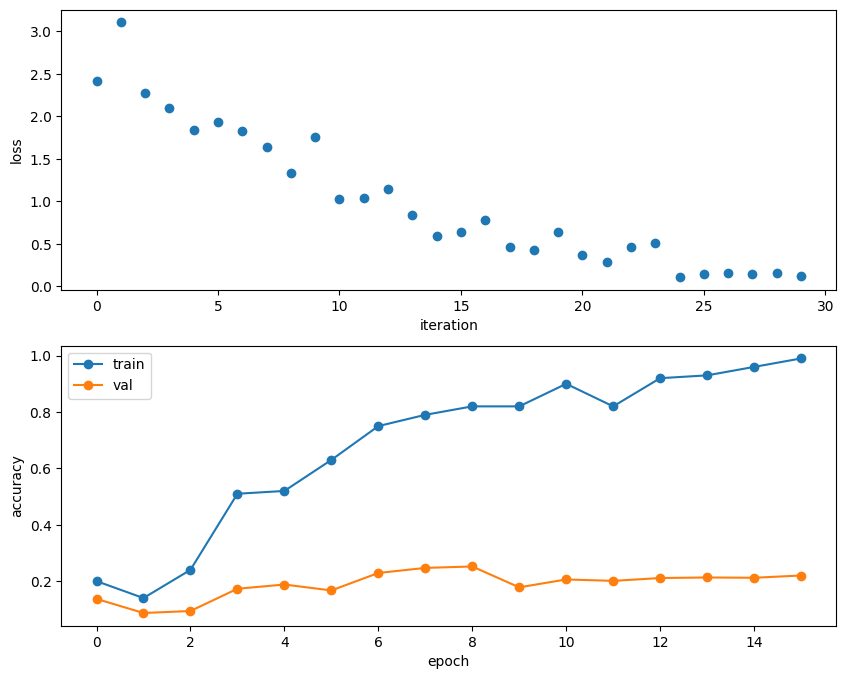

In [18]:
plt.subplot(2, 1, 1)
plt.plot(solver.loss_history, 'o')
plt.xlabel('iteration')
plt.ylabel('loss')

plt.subplot(2, 1, 2)
plt.plot(solver.train_acc_history, '-o')
plt.plot(solver.val_acc_history, '-o')
plt.legend(['train', 'val'], loc='upper left')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

## 训练网络

将三层卷积网络训练一个 epoch 后，你在训练集上的准确率应超过 40%：

In [19]:
model = ThreeLayerConvNet(weight_scale=0.001, hidden_dim=500, reg=0.001)

solver = Solver(
    model,
    data,
    num_epochs=1,
    batch_size=50,
    update_rule='adam',
    optim_config={'learning_rate': 1e-3,},
    verbose=True,
    print_every=20
)
solver.train()

(Iteration 1 / 980) loss: 2.304740
(Epoch 0 / 1) train acc: 0.103000; val_acc: 0.107000
(Iteration 21 / 980) loss: 2.098229
(Iteration 41 / 980) loss: 1.949788
(Iteration 61 / 980) loss: 1.888398
(Iteration 81 / 980) loss: 1.877093
(Iteration 101 / 980) loss: 1.851877
(Iteration 121 / 980) loss: 1.859353
(Iteration 141 / 980) loss: 1.800181
(Iteration 161 / 980) loss: 2.143292
(Iteration 181 / 980) loss: 1.830573
(Iteration 201 / 980) loss: 2.037280
(Iteration 221 / 980) loss: 2.020304
(Iteration 241 / 980) loss: 1.823728
(Iteration 261 / 980) loss: 1.692679
(Iteration 281 / 980) loss: 1.882594
(Iteration 301 / 980) loss: 1.798261
(Iteration 321 / 980) loss: 1.851960
(Iteration 341 / 980) loss: 1.716323
(Iteration 361 / 980) loss: 1.897655
(Iteration 381 / 980) loss: 1.319744
(Iteration 401 / 980) loss: 1.738790
(Iteration 421 / 980) loss: 1.488866
(Iteration 441 / 980) loss: 1.718409
(Iteration 461 / 980) loss: 1.744440
(Iteration 481 / 980) loss: 1.605460
(Iteration 501 / 980) loss: 

In [20]:
# Print final training accuracy.
print(
    "Full data training accuracy:",
    solver.check_accuracy(data['X_train'], data['y_train'])
)

Full data training accuracy: 0.4761836734693878


In [21]:
# Print final validation accuracy.
print(
    "Full data validation accuracy:",
    solver.check_accuracy(data['X_val'], data['y_val'])
)

Full data validation accuracy: 0.499


## 可视化滤波器

运行以下代码，可以将训练后网络第一层的卷积滤波器可视化：

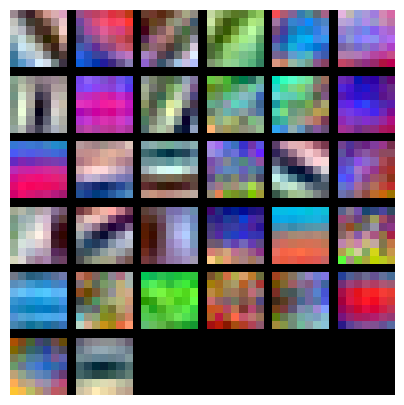

In [22]:
from cs231n.vis_utils import visualize_grid

grid = visualize_grid(model.params['W1'].transpose(0, 2, 3, 1))
plt.imshow(grid.astype('uint8'))
plt.axis('off')
plt.gcf().set_size_inches(5, 5)
plt.show()

# 空间批量归一化

我们已经看到，批量归一化是训练深度全连接网络的一项非常有用的技术。正如原始论文（链接见 `BatchNormalization.ipynb`）所提出的，批量归一化也可以用于卷积网络，不过需要稍作调整；这种修改称为“空间批量归一化”（spatial batch normalization）。

通常，批量归一化接收形状为 `(N, D)` 的输入，并生成形状为 `(N, D)` 的输出，其中我们沿小批量维度 `N` 进行归一化。对于来自卷积层的数据，批量归一化需要接收形状为 `(N, C, H, W)` 的输入，并生成形状为 `(N, C, H, W)` 的输出，其中 `N` 维表示小批量大小，`(H, W)` 维表示特征图的空间尺寸。

如果特征图由卷积生成，那么我们预期每个特征通道的统计量（例如均值、方差）在不同图像之间以及同一图像的不同位置之间都相对一致——毕竟，每个特征通道都是由同一个卷积滤波器生成的！因此，空间批量归一化通过在小批量维度 `N` 以及空间维度 `H` 和 `W` 上计算统计量，为 `C` 个特征通道中的每一个计算均值和方差。


[1] [Sergey Ioffe and Christian Szegedy, “Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift”, ICML 2015.](https://arxiv.org/abs/1502.03167)

# 空间批量归一化：前向传播

请在文件 `cs231n/layers.py` 的函数 `spatial_batchnorm_forward` 中实现空间批量归一化的前向传播。运行以下代码检查你的实现：

In [ ]:
np.random.seed(231)

# Check the training-time forward pass by checking means and variances
# of features both before and after spatial batch normalization.
N, C, H, W = 2, 3, 4, 5
x = 4 * np.random.randn(N, C, H, W) + 10

print('Before spatial batch normalization:')
print('  shape: ', x.shape)
print('  means: ', x.mean(axis=(0, 2, 3)))
print('  stds: ', x.std(axis=(0, 2, 3)))

# Means should be close to zero and stds close to one
gamma, beta = np.ones(C), np.zeros(C)
bn_param = {'mode': 'train'}
out, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)
print('After spatial batch normalization:')
print('  shape: ', out.shape)
print('  means: ', out.mean(axis=(0, 2, 3)))
print('  stds: ', out.std(axis=(0, 2, 3)))

# Means should be close to beta and stds close to gamma
gamma, beta = np.asarray([3, 4, 5]), np.asarray([6, 7, 8])
out, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)
print('After spatial batch normalization (nontrivial gamma, beta):')
print('  shape: ', out.shape)
print('  means: ', out.mean(axis=(0, 2, 3)))
print('  stds: ', out.std(axis=(0, 2, 3)))

In [ ]:
np.random.seed(231)

# Check the test-time forward pass by running the training-time
# forward pass many times to warm up the running averages, and then
# checking the means and variances of activations after a test-time
# forward pass.
N, C, H, W = 10, 4, 11, 12

bn_param = {'mode': 'train'}
gamma = np.ones(C)
beta = np.zeros(C)
for t in range(50):
  x = 2.3 * np.random.randn(N, C, H, W) + 13
  spatial_batchnorm_forward(x, gamma, beta, bn_param)
bn_param['mode'] = 'test'
x = 2.3 * np.random.randn(N, C, H, W) + 13
a_norm, _ = spatial_batchnorm_forward(x, gamma, beta, bn_param)

# Means should be close to zero and stds close to one, but will be
# noisier than training-time forward passes.
print('After spatial batch normalization (test-time):')
print('  means: ', a_norm.mean(axis=(0, 2, 3)))
print('  stds: ', a_norm.std(axis=(0, 2, 3)))

# 空间批量归一化：反向传播

请在文件 `cs231n/layers.py` 的函数 `spatial_batchnorm_backward` 中实现空间批量归一化的反向传播。运行以下代码，使用数值梯度检查来验证你的实现：

In [ ]:
np.random.seed(231)
N, C, H, W = 2, 3, 4, 5
x = 5 * np.random.randn(N, C, H, W) + 12
gamma = np.random.randn(C)
beta = np.random.randn(C)
dout = np.random.randn(N, C, H, W)

bn_param = {'mode': 'train'}
fx = lambda x: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]
fb = lambda b: spatial_batchnorm_forward(x, gamma, beta, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma, dout)
db_num = eval_numerical_gradient_array(fb, beta, dout)

#You should expect errors of magnitudes between 1e-12~1e-06
_, cache = spatial_batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = spatial_batchnorm_backward(dout, cache)
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

# 空间组归一化

在前一个 notebook 中，我们提到层归一化（Layer Normalization）是一种替代归一化技术，可以缓解批量归一化（Batch Normalization）受批量大小限制的问题。然而，正如 [2] 的作者所观察到的，层归一化用于卷积层时，效果不如批量归一化：

>对于全连接层，一层中的所有隐藏单元往往对最终预测做出相似的贡献，因此对某一层的输入总和重新居中并重新缩放会有很好的效果。然而，对于卷积神经网络，这种贡献相似的假设不再成立。感受野位于图像边界附近的大量隐藏单元很少被激活，因此它们的统计特征与同一层中其余隐藏单元大不相同。

[3] 的作者提出了一种折中技术。层归一化会对每个数据点的整个特征进行归一化；与之不同，他们建议将每个数据点的特征以一致的方式划分为 G 组，并对每个数据点的每一组分别进行归一化。

<p align="center">
<img src="https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/a2/normalization.png">
</p>
<center>目前所讨论的归一化技术的直观对比（图片改编自 [3]）</center>

尽管每个组内仍然假设各特征贡献相等，但作者认为这并不会造成太大问题，因为用于视觉识别的特征中本身就会形成分组。他们举例说明：传统计算机视觉中的许多高性能手工特征，都包含被明确分组的项。例如方向梯度直方图（Histogram of Oriented Gradients）[4]——先为每个空间局部块计算直方图，再对每个块的直方图进行归一化，最后将它们拼接起来形成最终特征向量。

现在你将实现组归一化（Group Normalization）。

[2] [Ba, Jimmy Lei, Jamie Ryan Kiros, and Geoffrey E. Hinton. “Layer Normalization.” stat 1050 (2016): 21.](https://arxiv.org/pdf/1607.06450.pdf)


[3] [Wu, Yuxin, and Kaiming He. “Group Normalization.” arXiv preprint arXiv:1803.08494 (2018).](https://arxiv.org/abs/1803.08494)


[4] [N. Dalal and B. Triggs. Histograms of oriented gradients for
human detection. In Computer Vision and Pattern Recognition
(CVPR), 2005.](https://ieeexplore.ieee.org/abstract/document/1467360/)

# 空间组归一化：前向传播

请在文件 `cs231n/layers.py` 的函数 `spatial_groupnorm_forward` 中实现组归一化的前向传播。运行以下代码检查你的实现：

In [ ]:
np.random.seed(231)

# Check the training-time forward pass by checking means and variances
# of features both before and after spatial batch normalization.
N, C, H, W = 2, 6, 4, 5
G = 2
x = 4 * np.random.randn(N, C, H, W) + 10
x_g = x.reshape((N*G,-1))
print('Before spatial group normalization:')
print('  shape: ', x.shape)
print('  means: ', x_g.mean(axis=1))
print('  stds: ', x_g.std(axis=1))

# Means should be close to zero and stds close to one
gamma, beta = np.ones((1,C,1,1)), np.zeros((1,C,1,1))
bn_param = {'mode': 'train'}

out, _ = spatial_groupnorm_forward(x, gamma, beta, G, bn_param)
out_g = out.reshape((N*G,-1))
print('After spatial group normalization:')
print('  shape: ', out.shape)
print('  means: ', out_g.mean(axis=1))
print('  stds: ', out_g.std(axis=1))

# 空间组归一化：反向传播

请在文件 `cs231n/layers.py` 的函数 `spatial_groupnorm_backward` 中实现空间组归一化的反向传播。运行以下代码，使用数值梯度检查来验证你的实现：

In [ ]:
np.random.seed(231)
N, C, H, W = 2, 6, 4, 5
G = 2
x = 5 * np.random.randn(N, C, H, W) + 12
gamma = np.random.randn(1,C,1,1)
beta = np.random.randn(1,C,1,1)
dout = np.random.randn(N, C, H, W)

gn_param = {}
fx = lambda x: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]
fg = lambda a: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]
fb = lambda b: spatial_groupnorm_forward(x, gamma, beta, G, gn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma, dout)
db_num = eval_numerical_gradient_array(fb, beta, dout)

_, cache = spatial_groupnorm_forward(x, gamma, beta, G, gn_param)
dx, dgamma, dbeta = spatial_groupnorm_backward(dout, cache)

# You should expect errors of magnitudes between 1e-12 and 1e-07.
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))